In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.Align import substitution_matrices
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_auc_score
import joblib
import os

## mcyA Mutation Impact Predictor - Machine Learning Model

In [2]:
mapped_scores =  pd.read_csv('data/mapped_scores.csv')

In [3]:
mapped_scores

,PDB_ResNum,Residue,Conservation_Score,Shannon_Entropy
0,1269,Q,0.968421,0.202249
1,1270,E,1.000000,0.000000
2,1271,V,1.000000,0.000000
3,1272,R,1.000000,0.000000
4,1273,L,0.821053,0.735525
...,...,...,...,...
1018,2302,A,1.000000,0.000000
1019,2303,D,1.000000,0.000000
1020,2304,Y,1.000000,0.000000
1021,2305,S,1.000000,0.000000


In [4]:
aa_props = {
    'A': {'charge': 0, 'hydrophobicity': 1.8, 'class': 'nonpolar'},
    'R': {'charge': 1, 'hydrophobicity': -4.5, 'class': 'basic'}, 
    'N': {'charge': 0, 'hydrophobicity': -3.5, 'class': 'polar'},
    'D': {'charge': -1, 'hydrophobicity': -3.5, 'class': 'acidic'},
    'C': {'charge': 0, 'hydrophobicity': 2.5, 'class': 'polar'},
    'Q': {'charge': 0, 'hydrophobicity': -3.5, 'class': 'polar'},
    'E': {'charge': -1, 'hydrophobicity': -3.5, 'class': 'acidic'},
    'G': {'charge': 0, 'hydrophobicity': -0.4, 'class': 'nonpolar'},
    'H': {'charge': 0, 'hydrophobicity': -3.2, 'class': 'polar'},
    'I': {'charge': 0, 'hydrophobicity': 4.5, 'class': 'nonpolar'},
    'L': {'charge': 0, 'hydrophobicity': 3.8, 'class': 'nonpolar'},
    'K': {'charge': 1, 'hydrophobicity': -3.9, 'class': 'basic'},
    'M': {'charge': 0, 'hydrophobicity': 1.9, 'class': 'nonpolar'},
    'F': {'charge': 0, 'hydrophobicity': 2.8, 'class': 'aromatic'},
    'P': {'charge': 0, 'hydrophobicity': -1.6, 'class': 'nonpolar'},
    'S': {'charge': 0, 'hydrophobicity': -0.8, 'class': 'polar'},
    'T': {'charge': 0, 'hydrophobicity': -0.7, 'class': 'polar'},
    'W': {'charge': 0, 'hydrophobicity': -0.9, 'class': 'aromatic'},
    'Y': {'charge': 0, 'hydrophobicity': -1.3, 'class': 'aromatic'},
    'V': {'charge': 0, 'hydrophobicity': 4.2, 'class': 'nonpolar'}
}

The BLOSUM substitution matrix is a quantitative method designed to determine whether an amino acid substitution is conservative or nonconservative. BLOSUM scores run from +11 to -4: more positive values are classified as conservative, and more negative values are classified as non-conservative. 

In [5]:
blosum62 = substitution_matrices.load("BLOSUM62")

In [6]:
score = blosum62['A', 'R']
print("Test: A->K substitution score =", score)

Test: A->K substitution score = -1.0


In [7]:
def get_blosum_score(aa1, aa2):
    try:
        return blosum62[(aa1, aa2)]
    except:
        return 0

In [8]:
print(f"Test: A->K substitution score = {get_blosum_score('A', 'R')}")

Test: A->K substitution score = -1.0


In [9]:
amino_acids = list(aa_props.keys())
mutations = []
n_mutations = 2000

In [14]:
for i in range(n_mutations):
    # Pick random position from dataframe
    pos_idx = np.random.randint(0, len(mapped_scores))
    pos_data = mapped_scores.iloc[pos_idx]

    wildtype = pos_data['Residue']
    mutant = np.random.choice(amino_acids)

    if wildtype == mutant:
        continue

    # Get properties
    wt = aa_props[wildtype]
    mut = aa_props[mutant]

    mutation = {
        'conservation_score': pos_data['Conservation_Score'],
        'shannon_entropy': pos_data['Shannon_Entropy'],
        'blosum_score': get_blosum_score(wildtype, mutant),
        'charge_change': abs(mut['charge'] - wt['charge']),
        'hydrophobicity_change': abs(mut['hydrophobicity'] - wt['hydrophobicity']),
        'class_change': int(mut['class'] != wt['class'])
    }

    # Impact calculation
    impact_score = (
    mutation['conservation_score'] * 0.3 +
    (2.0 - min(mutation['shannon_entropy'], 2.0)) * 0.2 +
    max(0, -mutation['blosum_score']) / 8.0 * 0.25 +
    mutation['charge_change'] * 0.15 +
    mutation['class_change'] * 0.05
    )

    # Add noise and create binary label
    impact_score += np.random.normal(0, 0.1)
    mutation['is_disruptive'] = int(impact_score > 0.7)
    
    mutations.append(mutation)

In [15]:
mut_df = pd.DataFrame(mutations)

In [16]:
mut_df

,conservation_score,shannon_entropy,blosum_score,charge_change,hydrophobicity_change,class_change,is_disruptive
0,1.000000,0.000000,3.0,0,4.1,0,1
1,1.000000,0.000000,0.0,0,3.1,1,1
2,0.979167,0.146094,-1.0,0,4.5,1,1
3,1.000000,0.000000,0.0,0,0.4,1,1
4,1.000000,0.000000,-3.0,1,2.6,1,1
...,...,...,...,...,...,...,...
5719,1.000000,0.000000,0.0,1,0.4,1,1
5720,1.000000,0.000000,0.0,0,0.3,0,0
5721,1.000000,0.000000,-4.0,0,0.7,1,1
5722,0.989474,0.084262,0.0,0,2.4,0,1


In [17]:
X = mut_df.drop(columns=['is_disruptive'])
y = mut_df['is_disruptive']

In [18]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=1)

Random Forest is an ensemble machine learning algorithm that builds a "forest" of multiple decision trees to produce more accurate and stable predictions. `n_estimators` defines the number of trees in the forest, and `max-depth` defines the maximum depth of the tree. 

In [19]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [20]:
# Check the accuracy on the test data
accuracy_test = accuracy_score(y_test, rf.predict(X_test))

# Check the accuracy on the training data
accuracy_train = accuracy_score(y_train, rf.predict(X_train))

In [21]:
accuracy_train

0.9423364952571144

In [22]:
accuracy_test

0.9179278230500582

In [23]:
# Show feature importance
for feature, importance in zip(X.columns, rf.feature_importances_):
    print(f" {feature:<20} {importance:.3f}")

 conservation_score   0.282
 shannon_entropy      0.301
 blosum_score         0.102
 charge_change        0.075
 hydrophobicity_change 0.174
 class_change         0.066


In [24]:
# Test examples
test_cases = [
    {'name': 'D→K (high conservation)', 'wt': 'D', 'mut': 'K', 'cons': 0.95, 'entropy': 0.1},
    {'name': 'L→I (low conservation)', 'wt': 'L', 'mut': 'I', 'cons': 0.3, 'entropy': 1.5},
    {'name': 'S→F (medium conservation)', 'wt': 'S', 'mut': 'F', 'cons': 0.7, 'entropy': 0.8}
]

In [25]:
for test in test_cases:
    wt_props = aa_props[test['wt']]
    mut_props = aa_props[test['mut']]
    
    test_features = [[
        test['cons'],
        test['entropy'],
        get_blosum_score(test['wt'], test['mut']),
        abs(mut_props['charge'] - wt_props['charge']),
        abs(mut_props['hydrophobicity'] - wt_props['hydrophobicity']),
        int(mut_props['class'] != wt_props['class'])
    ]]
    
    prediction = rf.predict(test_features)[0]
    probability = rf.predict_proba(test_features)[0, 1]
    
    print(f"   {test['name']}: {'DISRUPTIVE' if prediction else 'NEUTRAL'} ({probability:.3f})")

   D→K (high conservation): DISRUPTIVE (0.979)
   L→I (low conservation): NEUTRAL (0.010)
   S→F (medium conservation): DISRUPTIVE (0.530)


/home/ubuntu/mbs-337/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/mbs-337/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/mbs-337/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/mbs-337/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/mbs-337/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but 

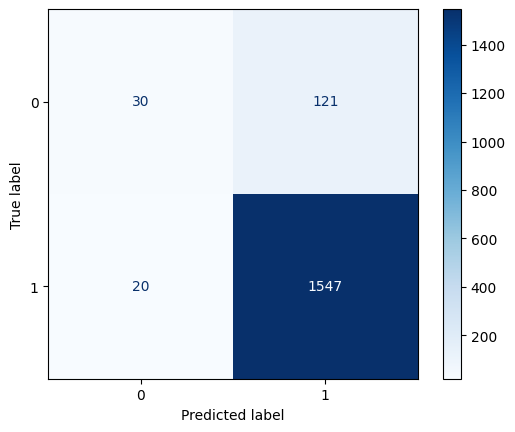

In [26]:
cm_display = ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap=plt.cm.Blues, normalize=None)

In [24]:
joblib.dump(rf, 'models/random_forest_model.pkl')
joblib.dump(X.columns, 'models/feature_names.pkl') 
joblib.dump(aa_props, 'models/aa_properties.pkl')

['models/aa_properties.pkl']

In [25]:
high_conservation = (mapped_scores['Conservation_Score'] > 0.9).sum()
total_residues = len(mapped_scores)
high_con_percent = high_conservation/total_residues * 100

In [26]:
print(high_con_percent)

95.01466275659824


In [27]:
# Cross-validation scores
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
cv_auc_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')

In [28]:
print(cv_scores.mean())

0.9932499788797837


In [30]:
print(cv_auc_scores.mean())

0.8961525633695444


In [31]:
# Test set performance
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

In [32]:
test_accuracy = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba)

In [33]:
print(test_accuracy)

0.9965034965034965


In [35]:
print(test_auc)

0.9980599647266314
